In [1]:
import os
import json
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from datetime import datetime

from geometry_param import get_params



In [2]:
# ============================================================
# LOAD TRAJECTORY
# ============================================================

traj_filename = "results/sim_data_LiteWing_yaw_23052026_1617.npz"

traj = np.load(traj_filename, allow_pickle=True)

t_hist  = traj['t']
n_hist  = traj['n']
nd_hist = traj['nd']

tau_true_hist = traj['tau'] if 'tau' in traj.files else None
F_true_hist   = traj['F']   if 'F' in traj.files else None

print("Trajectory loaded.")
print("t shape :", t_hist.shape)
print("n shape :", n_hist.shape)
print("nd shape:", nd_hist.shape)


Trajectory loaded.
t shape : (1000,)
n shape : (1000, 3)
nd shape: (1000, 3)


In [3]:
# ============================================================
# DESERIALIZATION
# ============================================================

SYMPY_LOCALS = {
    name: getattr(sp, name)
    for name in dir(sp)
}

SYMPY_LOCALS.update({
    "Derivative": sp.Derivative
})

def deserialize_fast(obj):

    if isinstance(obj, dict) and "__sympy__" in obj:
        return eval(obj["expr"], SYMPY_LOCALS)

    elif isinstance(obj, dict):
        return {
            k: deserialize_fast(v)
            for k, v in obj.items()
        }

    elif isinstance(obj, list):
        return [
            deserialize_fast(v)
            for v in obj
        ]

    else:
        return obj


In [4]:
# ============================================================
# LOAD SYMBOLIC MODEL
# ============================================================

symbolic_filename = "cache/3DOF_symbolic_data_08052026_1944.json"

with open(symbolic_filename, "r") as f:
    raw = json.load(f)

data = deserialize_fast(raw)

print("Symbolic model loaded.")

Symbolic model loaded.


In [5]:
# ============================================================
# EXTRACT SYMBOLICS
# ============================================================

M_sym = data['M']
h_sym = data['h']
Q_sym = data['Q']

C_AN_sym   = data['C_AN']
Jv_b_N_sym = data['Jv_b_N']
Jw_b_B_sym = data['Jw_b_B']


In [6]:
# ============================================================
# STATES
# ============================================================

n   = data['n']
nd  = data['nd']
ndd = data['ndd']

params_sym = data['params']


In [7]:
# ============================================================
# BUILD ARGUMENT LIST
# ============================================================

state_syms = list(n) + list(nd)

param_syms = list(params_sym.values())

tau_syms = sp.symbols('tau1 tau2 tau3')
F_syms   = sp.symbols('Fx Fy Fz')

dyn_args = (
    *state_syms,
    *param_syms,
    *tau_syms,
    *F_syms
)

In [8]:
# ============================================================
# CHECK SYMBOL CONSISTENCY
# ============================================================

free_syms = (
    M_sym.free_symbols
    | h_sym.free_symbols
    | Q_sym.free_symbols
    | C_AN_sym.free_symbols
    | Jv_b_N_sym.free_symbols
    | Jw_b_B_sym.free_symbols
)

missing = free_syms - set(dyn_args)

print("\nMissing symbols:")
print(missing)


Missing symbols:
set()


In [9]:
# ============================================================
# NUMERIC PARAMETERS
# ============================================================

params_num = get_params()

param_vals = list(params_num.values())


In [10]:
# ============================================================
# LAMBDIFY
# ============================================================

print("\nLambdifying dynamics...")

M_func = sp.lambdify(
    dyn_args,
    M_sym,
    modules='numpy'
)

h_func = sp.lambdify(
    dyn_args,
    h_sym,
    modules='numpy'
)

Q_func = sp.lambdify(
    dyn_args,
    Q_sym,
    modules='numpy'
)

print("Lambdifying Jacobians...")

Jv_func = sp.lambdify(
    dyn_args,
    Jv_b_N_sym,
    modules='numpy'
)

Jw_func = sp.lambdify(
    dyn_args,
    Jw_b_B_sym,
    modules='numpy'
)

CAN_func = sp.lambdify(
    dyn_args,
    C_AN_sym,
    modules='numpy'
)

print("Done.\n")



Lambdifying dynamics...
Lambdifying Jacobians...
Done.



In [11]:
# ============================================================
# ACCELERATION ESTIMATION
# ============================================================

print("Estimating accelerations...")

dt_mean = np.mean(np.diff(t_hist))

window_length = 21
polyorder      = 3

ndd_hist = savgol_filter(
    nd_hist,
    window_length=window_length,
    polyorder=polyorder,
    deriv=1,
    delta=dt_mean,
    axis=0
)

print("ndd shape:", ndd_hist.shape)


Estimating accelerations...
ndd shape: (1000, 3)


## Direct Wrench Estimation With Pseudo-Inverse

This notebook estimates the body-frame wrench directly from the simulated trajectory.

At each time step it computes the generalized force implied by the trajectory,
`Q_traj = M(q) qdd + h(q, qd)`, and then solves for the minimum-norm body wrench
`[F_B; tau_B]` using the Moore-Penrose pseudo-inverse of the wrench map
`A(q) = [Jv_B.T  Jw_B.T]`.

Because the rig gives only 3 generalized equations for 6 wrench unknowns, the
result is the minimum-norm wrench that reproduces the generalized force, not
necessarily the exact true quad wrench. The plots compare that estimate against
the true simulated force and torque histories saved by `3dof_simulate_2.ipynb`.



In [12]:
# ============================================================
# TRAJECTORY METADATA
# ============================================================
if 'quad_config' in traj.files:
    quad_config = traj['quad_config'].item()
    print('Trajectory quad config:')
    for key, value in quad_config.items():
        print(f'  {key}: {value}')
else:
    quad_config = {}
    print('WARN: trajectory file does not contain quad_config.')

pinv_rcond = 1e-9



Trajectory quad config:
  model_name: LiteWing
  spec_source_url: https://circuitdigest.com/wiki/litewing/
  frame_span_m: 0.1
  MANEUVER_MODE: yaw
  quad_l: 0.05
  body_mass_total_kg: 0.045
  body_inertia_diag: [5.625e-05 5.625e-05 1.125e-04]
  kf: 2e-08
  km: 2e-10
  hover_rpm: 11000.0
  roll_amplitude_rpm: 20000.0
  pitch_amplitude_rpm: 20000.0
  yaw_amplitude_rpm: 10000.0


In [13]:
# ============================================================
# STORAGE
# ============================================================
N = len(t_hist)

wrench_est_hist = np.zeros((N, 6))
F_est_hist = np.zeros((N, 3))
tau_est_hist = np.zeros((N, 3))

Q_hist = np.zeros((N, 3))
Q_model_hist = np.zeros((N, 3))
fit_residual_hist = np.zeros((N, 3))
rank_hist = np.zeros(N, dtype=int)
sigma_hist = np.zeros((N, 3))



In [14]:
# ============================================================
# ESTIMATION LOOP
# ============================================================
print("Estimating direct body wrench using pseudo-inverse...")

for k in range(N):
    q = n_hist[k]
    qd = nd_hist[k]
    qdd = ndd_hist[k]

    n1, n2, n3 = q
    n1d, n2d, n3d = qd

    tau_dummy = [0.0, 0.0, 0.0]
    F_dummy = [0.0, 0.0, 0.0]

    args = (
        n1, n2, n3,
        n1d, n2d, n3d,
        *param_vals,
        *tau_dummy,
        *F_dummy,
    )

    M_k = np.array(M_func(*args), dtype=float)
    h_k = np.array(h_func(*args), dtype=float).reshape(3)
    Q_k = M_k @ qdd + h_k

    Jv_N_k = np.array(Jv_func(*args), dtype=float)
    Jw_k = np.array(Jw_func(*args), dtype=float)
    C_AN_k = np.array(CAN_func(*args), dtype=float)

    # Convert translational Jacobian from inertial components to body/arm components.
    Jv_B_k = C_AN_k @ Jv_N_k

    A_k = np.hstack([Jv_B_k.T, Jw_k.T])
    A_pinv = np.linalg.pinv(A_k, rcond=pinv_rcond)
    wrench_est = A_pinv @ Q_k
    Q_model = A_k @ wrench_est
    fit_residual = Q_model - Q_k

    singular_values = np.linalg.svd(A_k, compute_uv=False)
    sigma_hist[k, :len(singular_values)] = singular_values
    rank_hist[k] = int(np.linalg.matrix_rank(A_k))

    wrench_est_hist[k] = wrench_est
    F_est_hist[k] = wrench_est[:3]
    tau_est_hist[k] = wrench_est[3:]
    Q_hist[k] = Q_k
    Q_model_hist[k] = Q_model
    fit_residual_hist[k] = fit_residual

print("Estimation complete.")
print("Max |Q fit residual|:", np.max(np.abs(fit_residual_hist)))
print("RMS |Q fit residual|:", np.sqrt(np.mean(fit_residual_hist**2)))
print("Observed wrench-map ranks:", np.unique(rank_hist))



Estimating direct body wrench using pseudo-inverse...
Estimation complete.
Max |Q fit residual|: 2.7755575615628914e-17
RMS |Q fit residual|: 5.845231617873235e-18
Observed wrench-map ranks: [3]


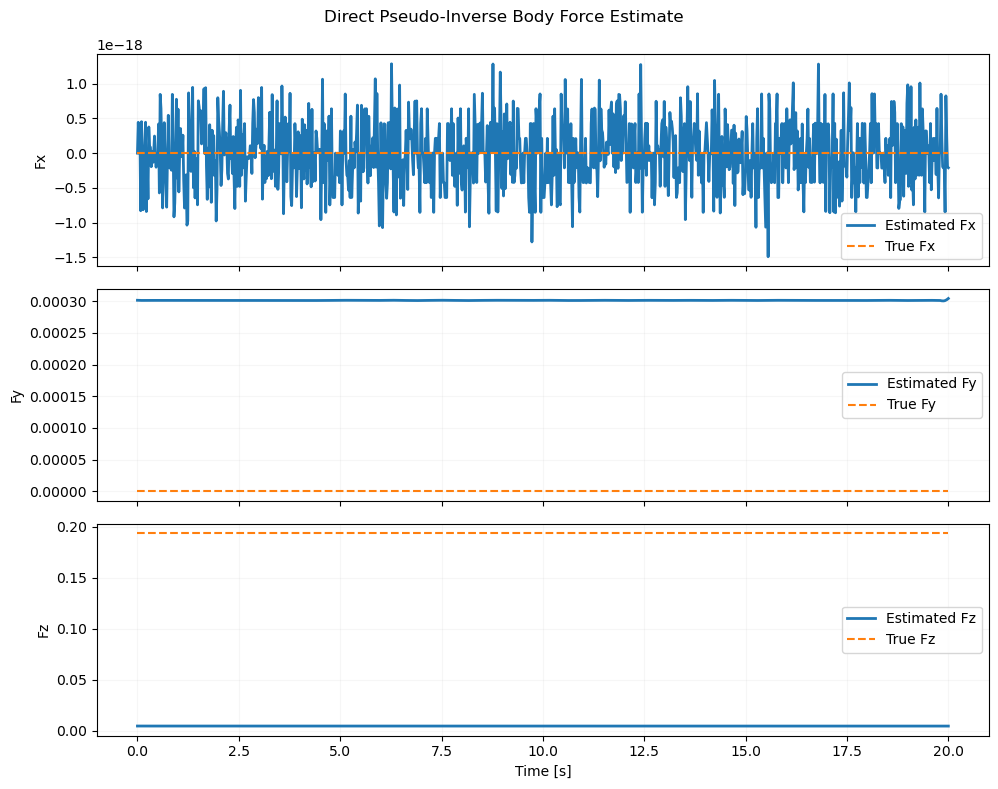

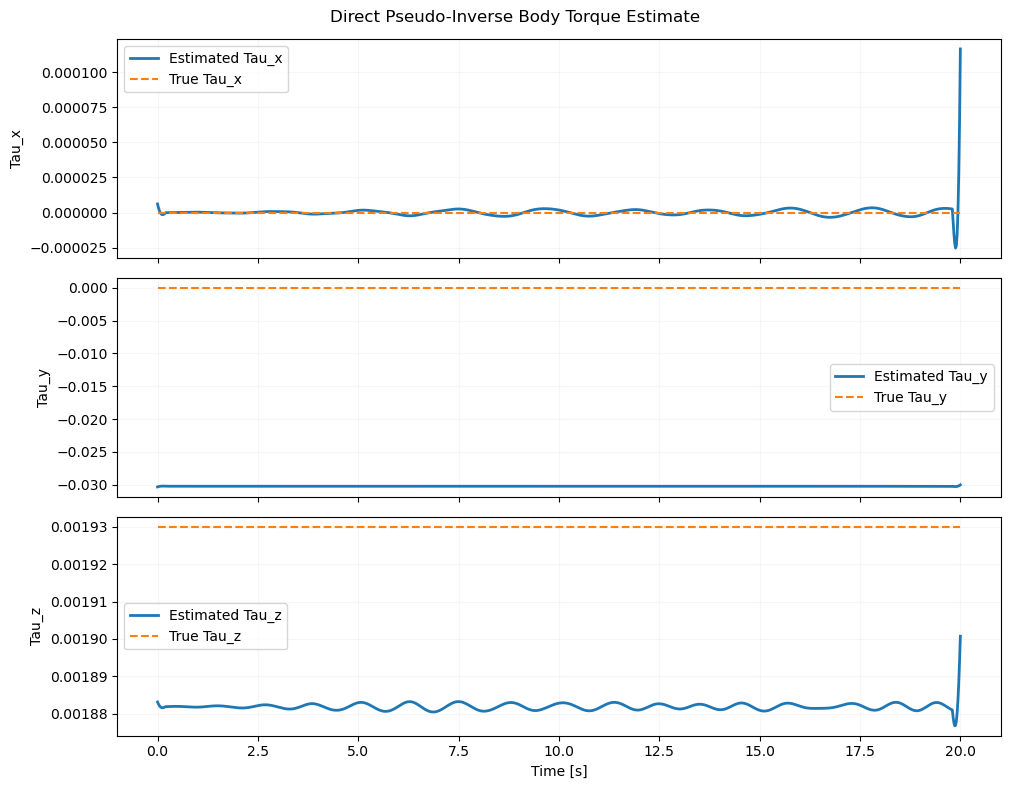

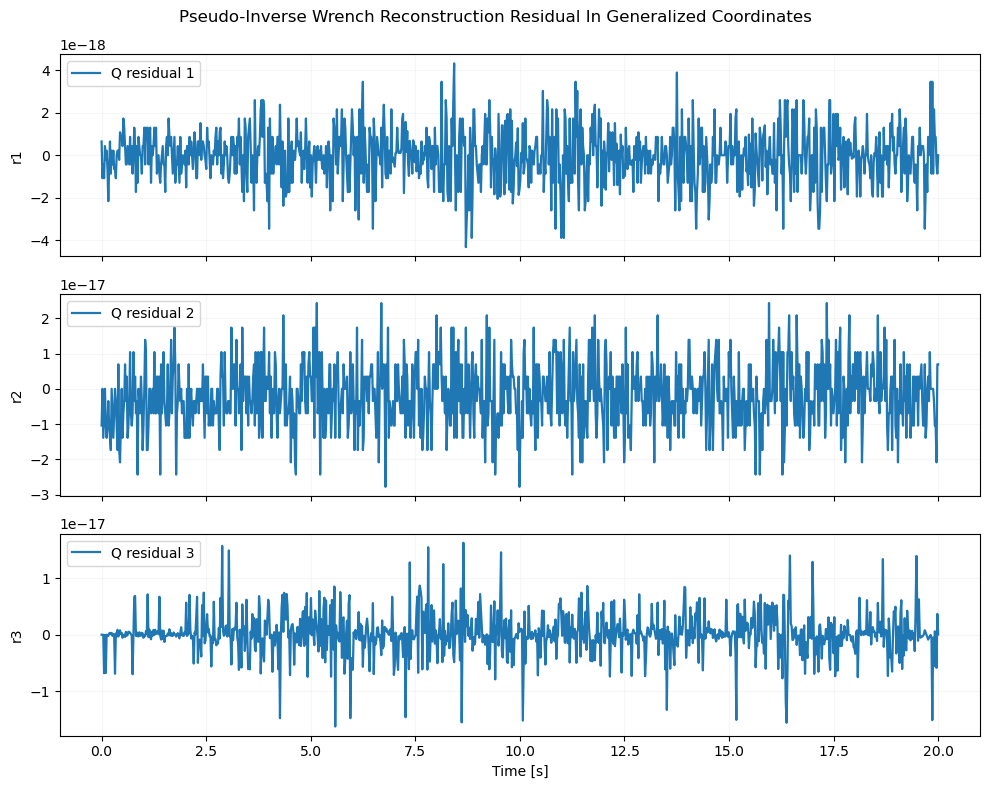

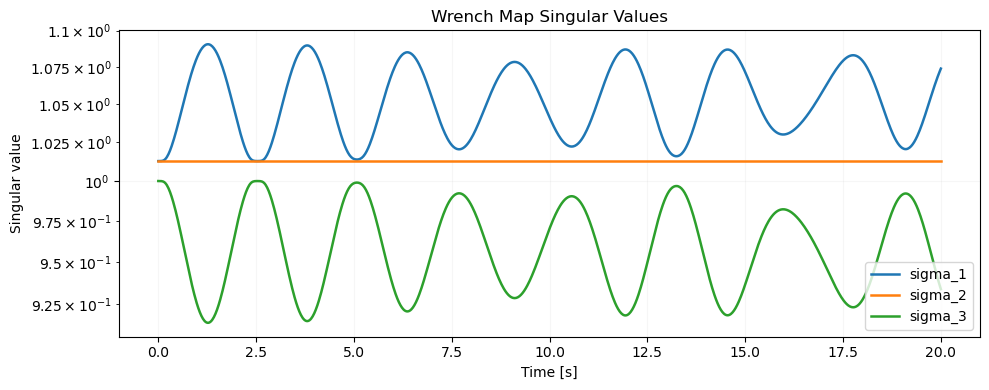

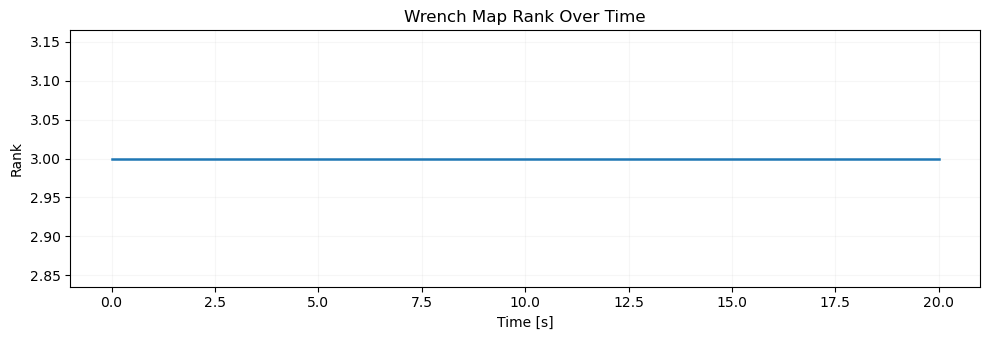

In [15]:
# ============================================================
# FORCE PLOTS
# ============================================================
figF, axF = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
force_labels = ['Fx', 'Fy', 'Fz']

for i, label in enumerate(force_labels):
    axF[i].plot(t_hist, F_est_hist[:, i], linewidth=2, label=f'Estimated {label}')
    if F_true_hist is not None:
        axF[i].plot(t_hist, F_true_hist[:, i], '--', linewidth=1.5, label=f'True {label}')
    axF[i].set_ylabel(label)
    axF[i].grid(True, alpha=0.1)
    axF[i].legend()

axF[-1].set_xlabel('Time [s]')
figF.suptitle('Direct Pseudo-Inverse Body Force Estimate')
plt.tight_layout()
plt.show()

# ============================================================
# TORQUE PLOTS
# ============================================================
figTau, axTau = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
tau_labels = ['Tau_x', 'Tau_y', 'Tau_z']

for i, label in enumerate(tau_labels):
    axTau[i].plot(t_hist, tau_est_hist[:, i], linewidth=2, label=f'Estimated {label}')
    if tau_true_hist is not None:
        axTau[i].plot(t_hist, tau_true_hist[:, i], '--', linewidth=1.5, label=f'True {label}')
    axTau[i].set_ylabel(label)
    axTau[i].grid(True, alpha=0.1)
    axTau[i].legend()

axTau[-1].set_xlabel('Time [s]')
figTau.suptitle('Direct Pseudo-Inverse Body Torque Estimate')
plt.tight_layout()
plt.show()

# ============================================================
# GENERALIZED-FORCE FIT RESIDUAL
# ============================================================
figQ, axQ = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i in range(3):
    axQ[i].plot(t_hist, fit_residual_hist[:, i], linewidth=1.6, label=f'Q residual {i + 1}')
    axQ[i].set_ylabel(f'r{i + 1}')
    axQ[i].grid(True, alpha=0.1)
    axQ[i].legend()

axQ[-1].set_xlabel('Time [s]')
figQ.suptitle('Pseudo-Inverse Wrench Reconstruction Residual In Generalized Coordinates')
plt.tight_layout()
plt.show()

# ============================================================
# SINGULAR VALUES / RANK DIAGNOSTICS
# ============================================================
plt.figure(figsize=(10, 4))
for i in range(sigma_hist.shape[1]):
    plt.plot(t_hist, sigma_hist[:, i], linewidth=1.8, label=f'sigma_{i + 1}')
plt.yscale('log')
plt.grid(True, alpha=0.1)
plt.xlabel('Time [s]')
plt.ylabel('Singular value')
plt.title('Wrench Map Singular Values')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3.5))
plt.plot(t_hist, rank_hist, linewidth=1.8)
plt.grid(True, alpha=0.1)
plt.xlabel('Time [s]')
plt.ylabel('Rank')
plt.title('Wrench Map Rank Over Time')
plt.tight_layout()
plt.show()



In [16]:
# ============================================================
# OPTIONAL SAVE
# ============================================================
SAVE_ESTIMATION = False

if SAVE_ESTIMATION:
    save_dir = "results"
    os.makedirs(save_dir, exist_ok=True)

    timestamp_now = datetime.now().strftime("%d%m%Y_%H%M")
    save_filename = os.path.join(
        save_dir,
        f"estimated_wrench_pinv_{timestamp_now}.npz"
    )

    np.savez_compressed(
        save_filename,
        t=t_hist,
        F_est=F_est_hist,
        tau_est=tau_est_hist,
        wrench_est=wrench_est_hist,
        Q=Q_hist,
        Q_model=Q_model_hist,
        Q_fit_residual=fit_residual_hist,
        sigma=sigma_hist,
        rank=rank_hist,
        pinv_rcond=pinv_rcond,
        quad_config=quad_config,
    )

    print(f"Saved estimated wrench data to: {save_filename}")

